In [13]:
import pandas as pd
import numpy as np
from mesa import batch_run
from model import UniversityRevenue

In [14]:
# Sweep through different degrees of revenue incentive and information levels
seeds = [2+i*10 for i in range(10)]
parameters = {
    "student_count": 1000,
    "university_count": 5,
    "donate": 0.5,
    "capacity_prop": 0.3,
    "merit_window": 1.0,
    "incentive": [0.0, 0.25, 0.5, 0.75, 1.0], 
    "information": ["No information", "Partial information", "Perfect information"],
    "seed": seeds
}

# Perform the run
results = batch_run(
    model_cls=UniversityRevenue,
    parameters=parameters,
    max_steps=50,
    data_collection_period=-1
)

  0%|          | 0/150 [00:00<?, ?it/s]

In [15]:
df = pd.DataFrame(results)

In [19]:
# Verify that a reasonable number of average steps were taken
df["Step"].mean()

9.46

In [20]:
# Only include columns which actually vary
df_clean = df[['incentive', 'information', 'Merit_std', 'Wealth_std', 'Tuition_Prestige_Corr', 'Total_Revenue']]

In [21]:
# Write to csv to avoid needing to re-run batches
df_clean.to_csv("batch_runs.csv")

In [24]:
# Re-load csv (if necessary)
df_clean = pd.read_csv("batch_runs.csv", index_col=0)

In [25]:
# Average all run values within matching parameter values
df_clean.groupby(['incentive', 'information']).mean()

Merit_std  Wealth_std  Tuition_Prestige_Corr  \
incentive information                                                         
0.00      No information        0.088133    0.291982               0.967857   
          Partial information   0.087069    0.225200               0.975792   
          Perfect information   0.085934    0.144617               0.978414   
0.25      No information        0.054026    0.185672               0.583009   
          Partial information   0.070351    0.234223               0.898921   
          Perfect information   0.069813    0.256362               0.988186   
0.50      No information        0.058652    0.162372               0.271069   
          Partial information   0.109636    0.220151               0.991237   
          Perfect information   0.111861    0.214562               0.986465   
0.75      No information        0.110207    0.143664               0.902439   
          Partial information   0.136746    0.174246               0.962910   
          Perfect information   0.146564    0.164597               0.818797   
1.00      No information        0.083300    0.080230               0.295651   
          Partial information   0.118746    0.125771               0.830254   
          Perfect information   0.147957    0.120122               0.910267   

                               Total_Revenue  
incentive information                         
0.00      No information           61.072772  
          Partial information      72.021644  
          Perfect information      84.742623  
0.25      No information           85.013527  
          Partial information      91.899436  
          Perfect information     109.824763  
0.50      No information          135.398903  
          Partial information     159.195919  
          Perfect information     174.499640  
0.75      No information          206.903958  
          Partial information     198.123463  
          Perfect information     219.666676  
1.00      No information          252.912660  
          Partial information     235.962391  
          Perfect information     272.702849

In [30]:
df_clean.groupby(['incentive', 'information']).mean().round(3)

Merit_std  Wealth_std  Tuition_Prestige_Corr  \
incentive information                                                         
0.00      No information           0.088       0.292                  0.968   
          Partial information      0.087       0.225                  0.976   
          Perfect information      0.086       0.145                  0.978   
0.25      No information           0.054       0.186                  0.583   
          Partial information      0.070       0.234                  0.899   
          Perfect information      0.070       0.256                  0.988   
0.50      No information           0.059       0.162                  0.271   
          Partial information      0.110       0.220                  0.991   
          Perfect information      0.112       0.215                  0.986   
0.75      No information           0.110       0.144                  0.902   
          Partial information      0.137       0.174                  0.963   
          Perfect information      0.147       0.165                  0.819   
1.00      No information           0.083       0.080                  0.296   
          Partial information      0.119       0.126                  0.830   
          Perfect information      0.148       0.120                  0.910   

                               Total_Revenue  
incentive information                         
0.00      No information              61.073  
          Partial information         72.022  
          Perfect information         84.743  
0.25      No information              85.014  
          Partial information         91.899  
          Perfect information        109.825  
0.50      No information             135.399  
          Partial information        159.196  
          Perfect information        174.500  
0.75      No information             206.904  
          Partial information        198.123  
          Perfect information        219.667  
1.00      No information             252.913  
          Partial information        235.962  
          Perfect information        272.703

In [32]:
df_clean.groupby(['incentive', 'information']).mean().round(3).to_csv("results.csv")

In [33]:
df_clean

,incentive,information,Merit_std,Wealth_std,Tuition_Prestige_Corr,Total_Revenue
0,0.0,No information,0.087599,0.292825,0.999984,28.665750
1,0.0,No information,0.083686,0.294424,0.961017,29.347645
2,0.0,No information,0.096150,0.300791,0.879447,40.680825
3,0.0,No information,0.079827,0.286957,0.999995,30.233618
4,0.0,No information,0.095564,0.282025,0.999904,78.516026
...,...,...,...,...,...,...
145,1.0,Perfect information,0.175391,0.146098,0.999203,297.273250
146,1.0,Perfect information,0.151086,0.136131,0.998055,293.249606
147,1.0,Perfect information,0.163804,0.109869,0.995092,309.148899
148,1.0,Perfect information,0.121480,0.169526,0.993940,217.366070


In [34]:
df_clean[['incentive', 'Merit_std', 'Wealth_std']]

,incentive,Merit_std,Wealth_std
0,0.0,0.087599,0.292825
1,0.0,0.083686,0.294424
2,0.0,0.096150,0.300791
3,0.0,0.079827,0.286957
4,0.0,0.095564,0.282025
...,...,...,...
145,1.0,0.175391,0.146098
146,1.0,0.151086,0.136131
147,1.0,0.163804,0.109869
148,1.0,0.121480,0.169526


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

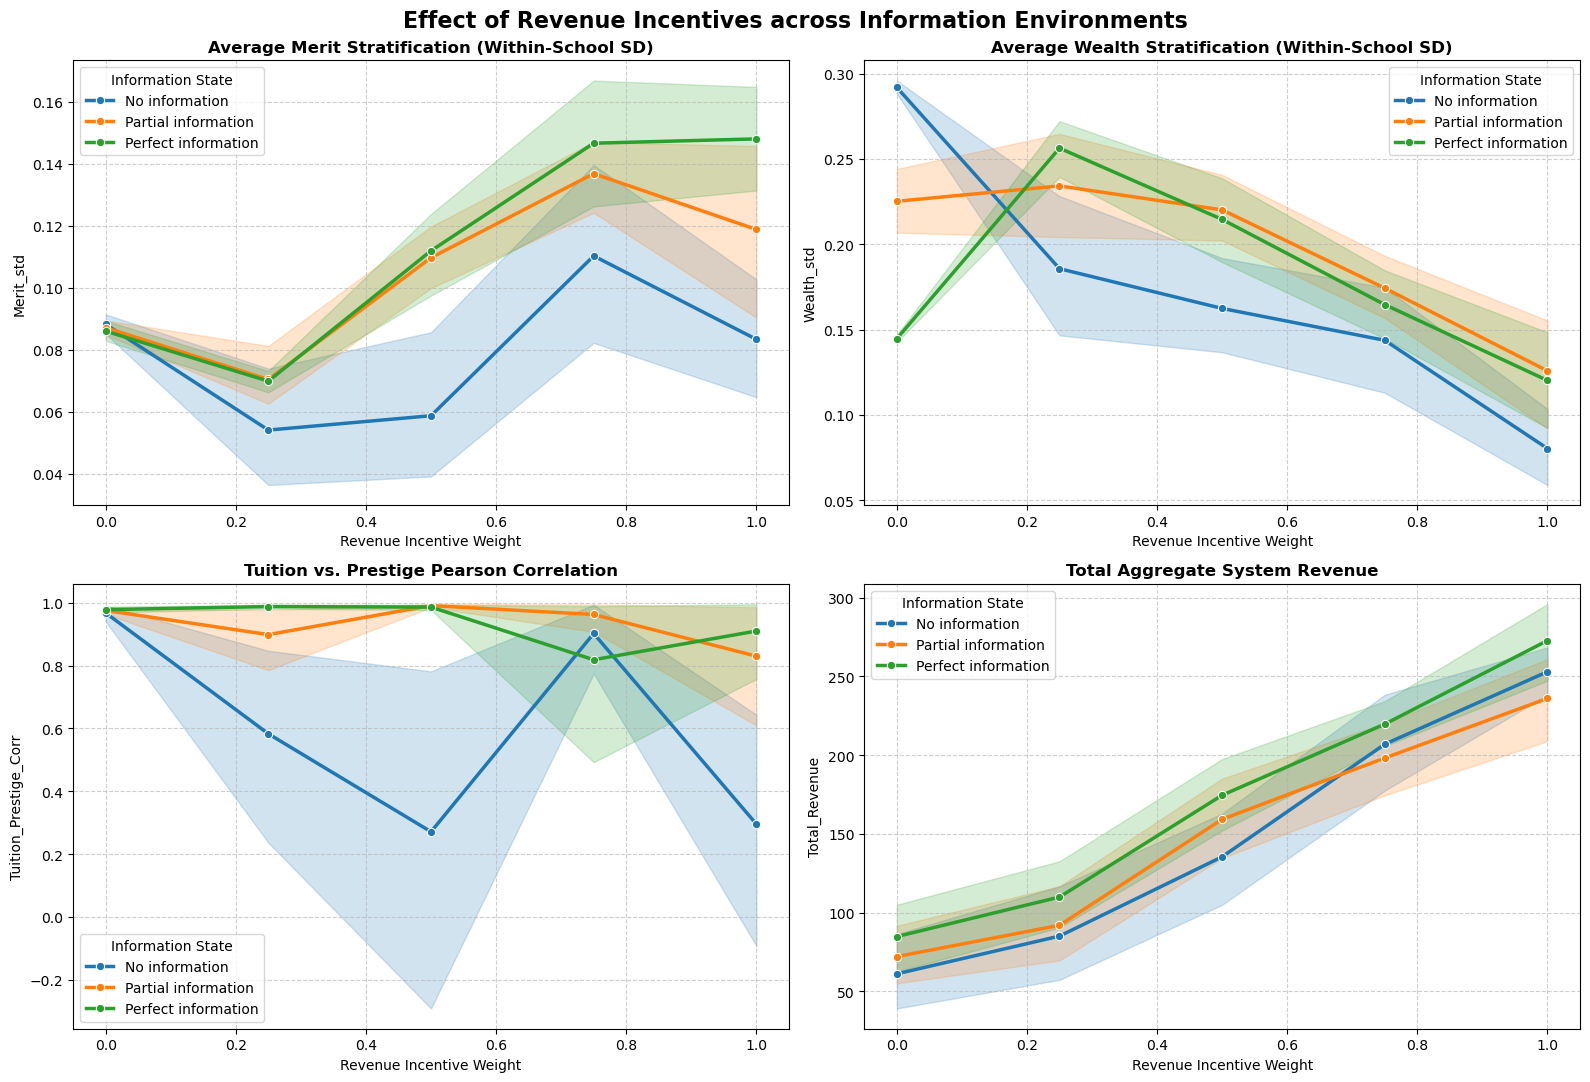

In [38]:
# Create a line plot grid for detailed trend inspection
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Effect of Revenue Incentives across Information Environments", fontsize=16, fontweight='bold')

for i, metric in enumerate(metrics):
    ax = axes[i // 2, i % 2]
    
    # sns.lineplot automatically groups matching parameters and computes 95% Confidence Intervals
    sns.lineplot(
        data=df_clean,
        x="incentive",
        y=metric,
        hue="information",
        marker="o",
        linewidth=2.5,
        ax=ax
    )
    
    ax.set_title(titles[i], fontsize=12, fontweight='semibold')
    ax.set_ylabel(metric)
    ax.set_xlabel("Revenue Incentive Weight")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(title="Information State")

plt.tight_layout()
plt.show()

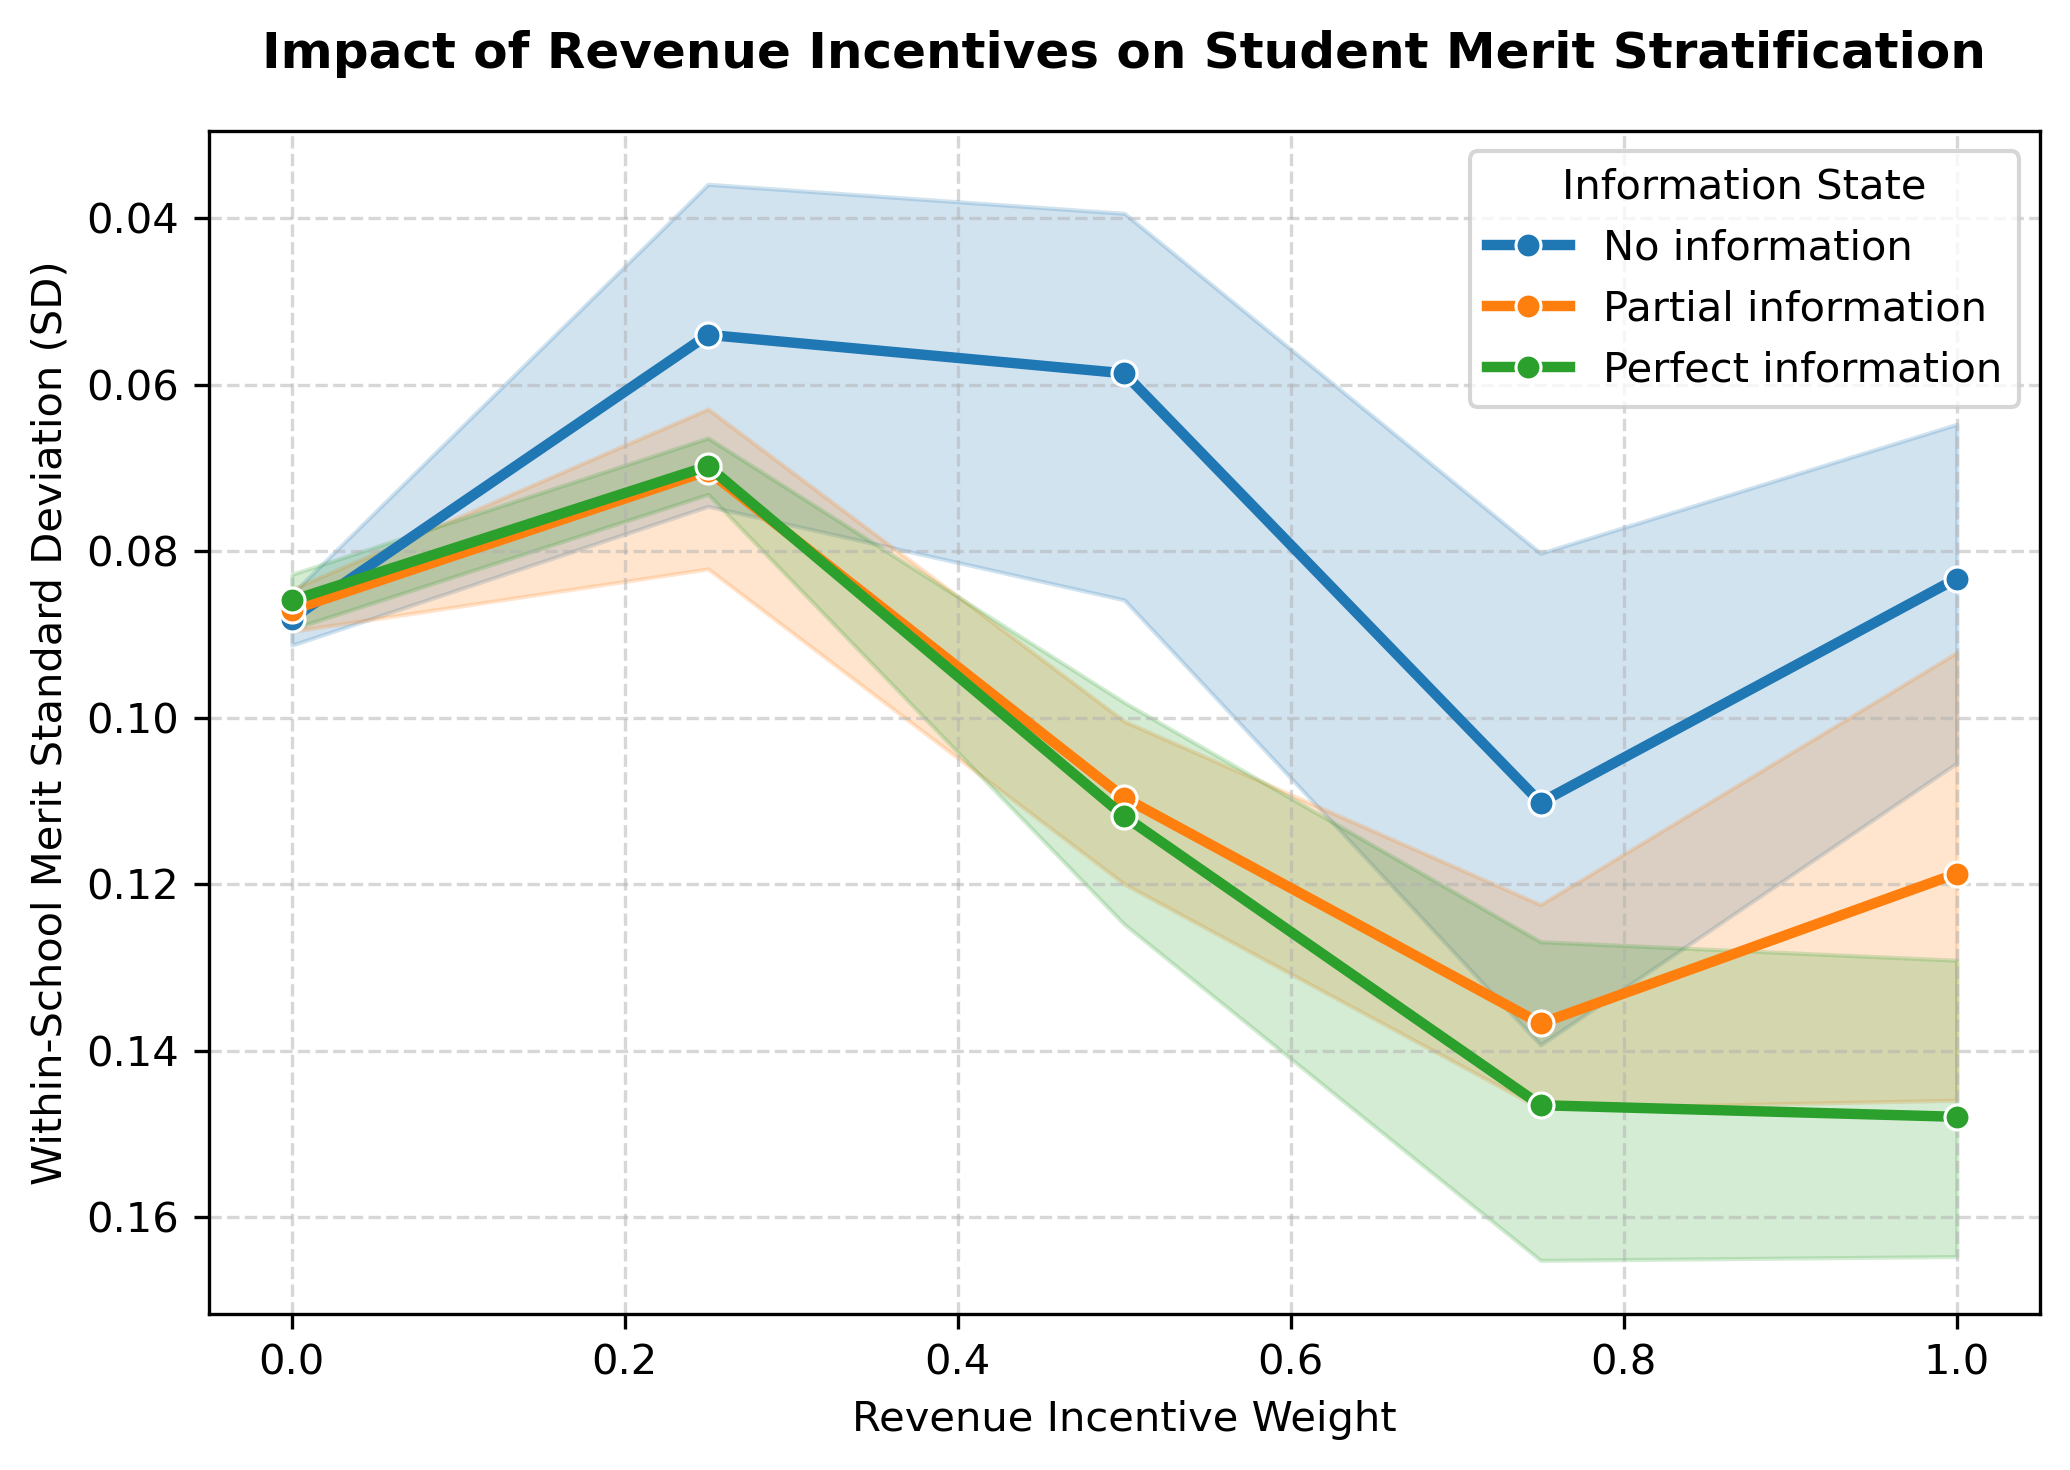

In [40]:
plt.figure(figsize=(7, 5), dpi=300)
sns.lineplot(
    data=df_clean,
    x="incentive",
    y="Merit_std",
    hue="information",
    marker="o",
    linewidth=2.5
)
plt.title("Impact of Revenue Incentives on Student Merit Stratification", fontsize=12, fontweight='bold', pad=15)
plt.ylabel("Within-School Merit Standard Deviation (SD)", fontsize=10)
plt.xlabel("Revenue Incentive Weight", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Information State", frameon=True)
plt.gca().invert_yaxis()
plt.tight_layout()

# Save the figure for your paper
plt.savefig("merit_stratification_plot.png", bbox_inches="tight")
plt.show()

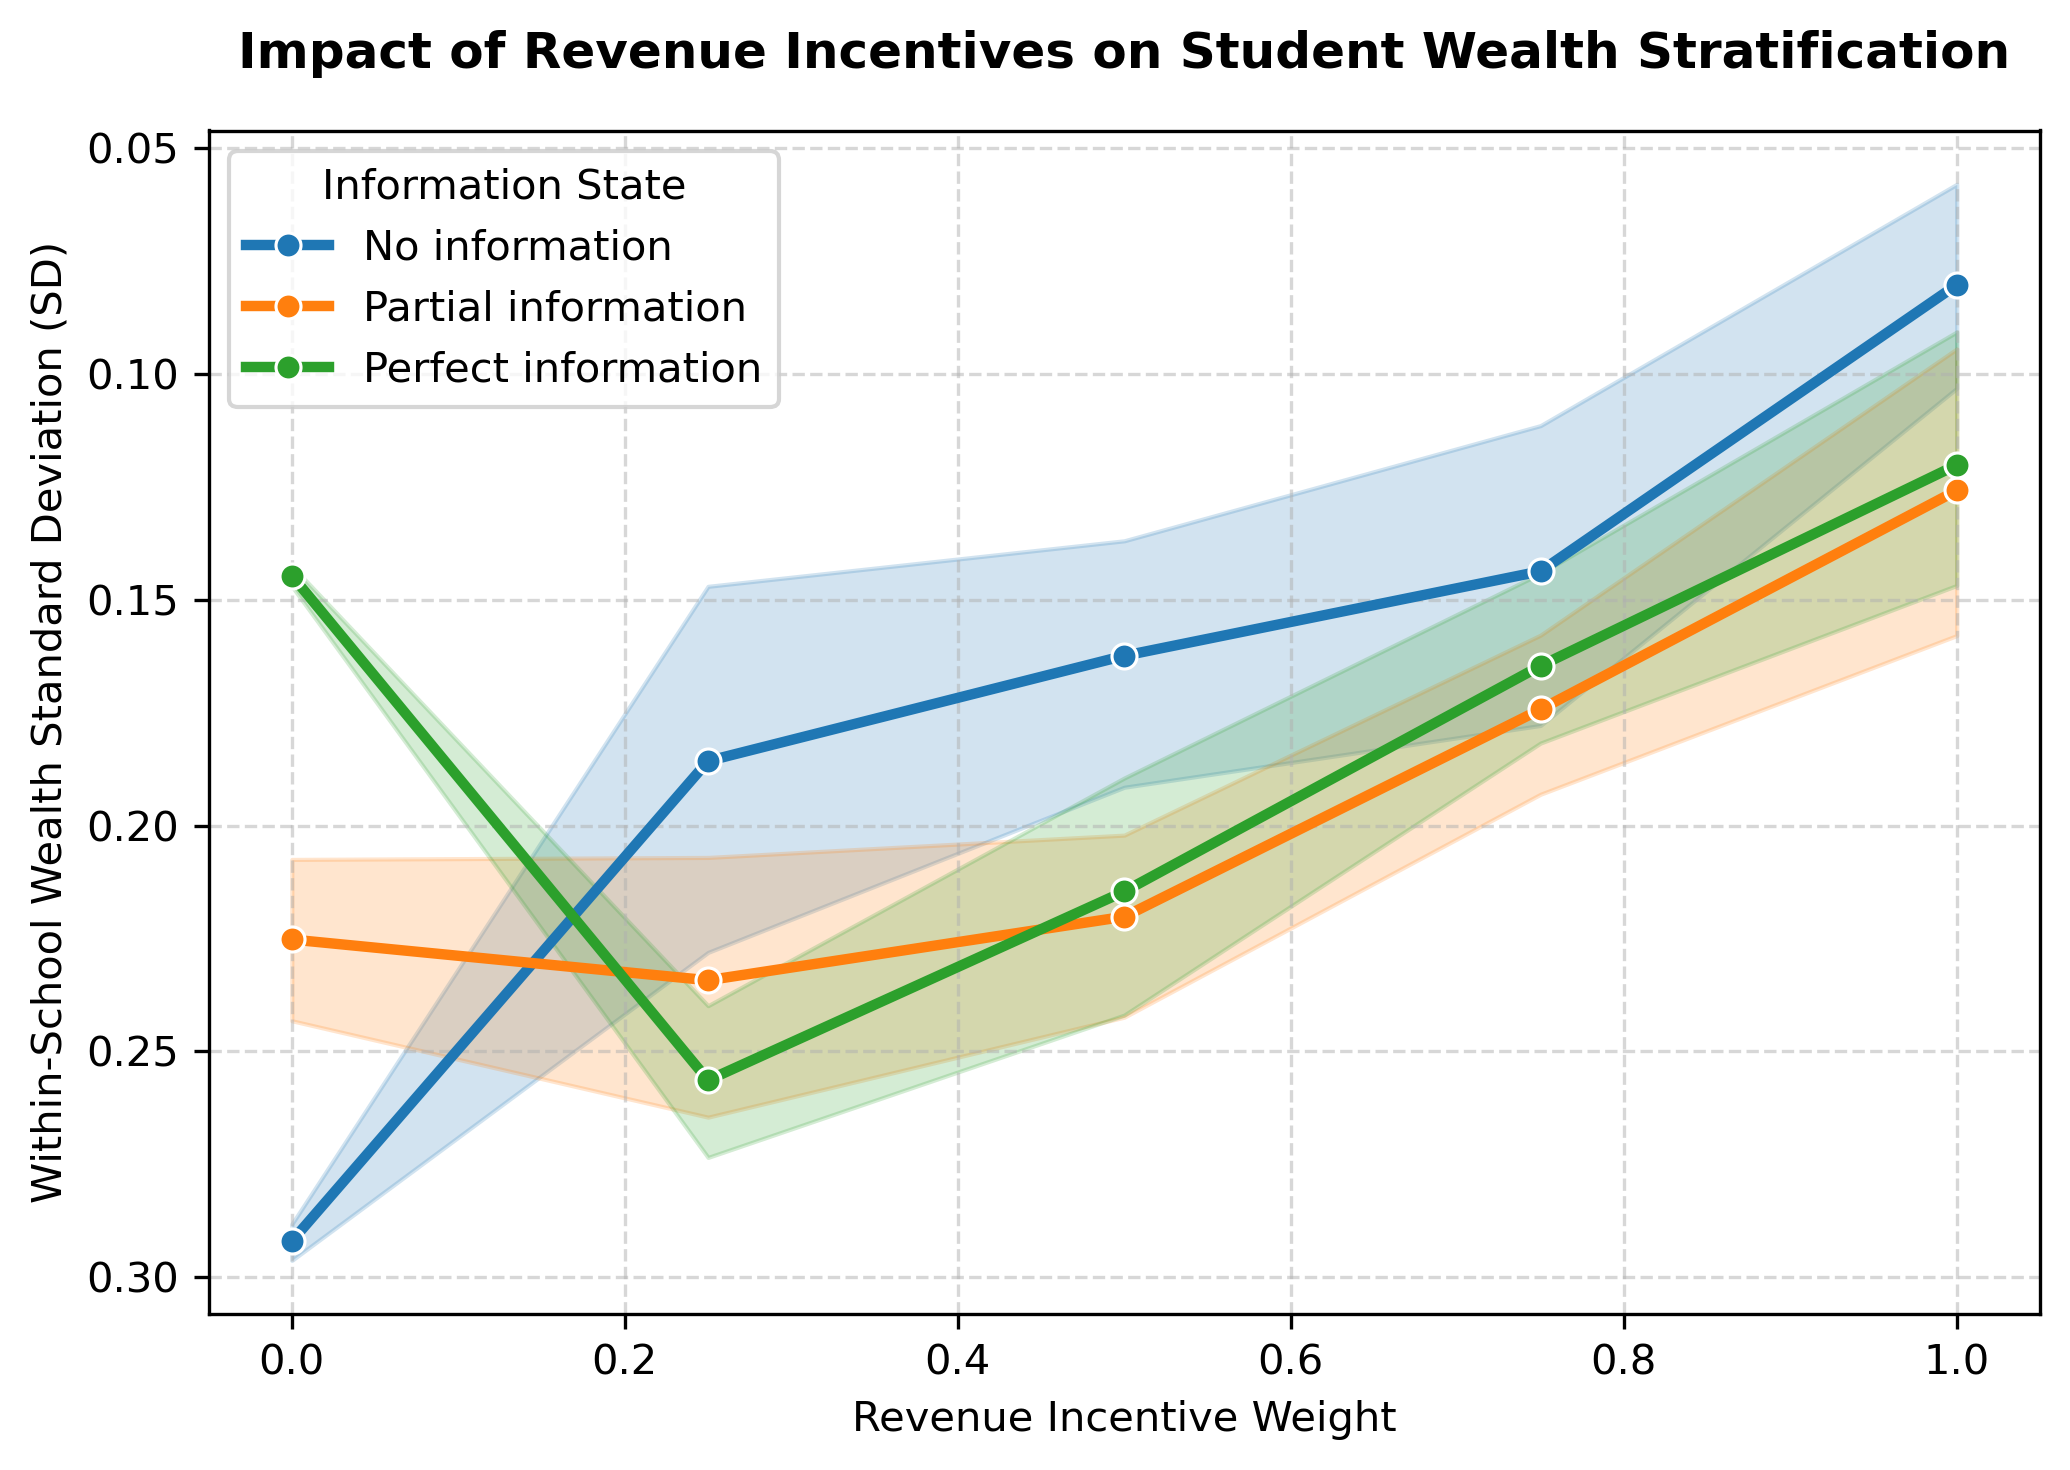

In [41]:
plt.figure(figsize=(7, 5), dpi=300)
sns.lineplot(
    data=df_clean,
    x="incentive",
    y="Wealth_std",
    hue="information",
    marker="o",
    linewidth=2.5
)
plt.title("Impact of Revenue Incentives on Student Wealth Stratification", fontsize=12, fontweight='bold', pad=15)
plt.ylabel("Within-School Wealth Standard Deviation (SD)", fontsize=10)
plt.xlabel("Revenue Incentive Weight", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Information State", frameon=True)
plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("wealth_stratification_plot.png", bbox_inches="tight")
plt.show()

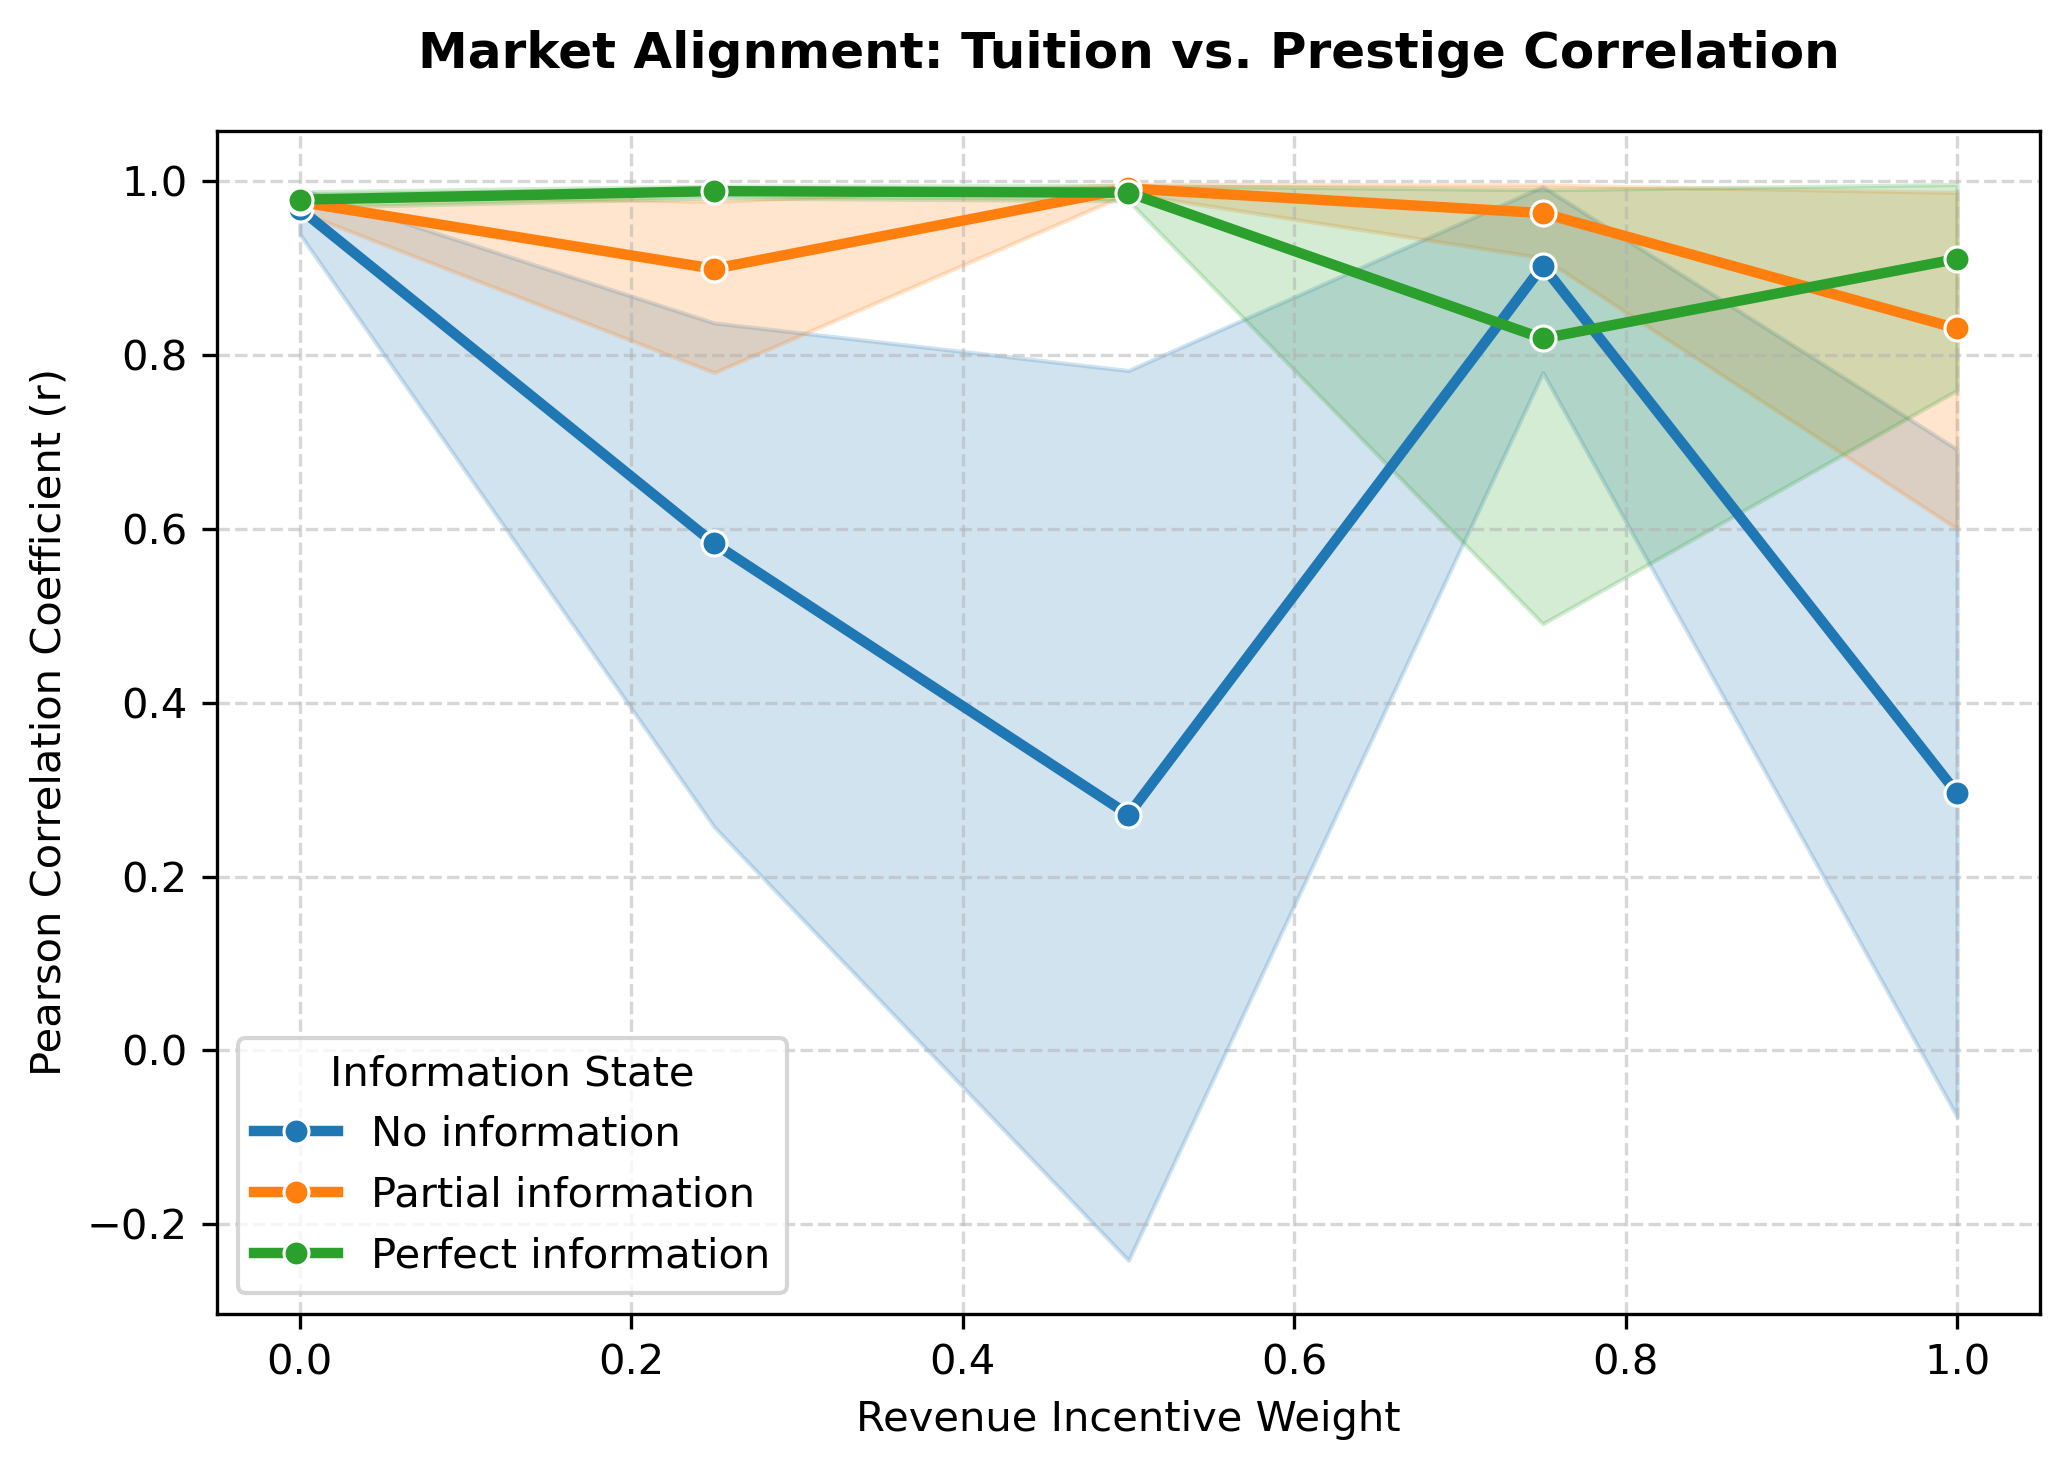

In [42]:
plt.figure(figsize=(7, 5), dpi=300)
sns.lineplot(
    data=df_clean,
    x="incentive",
    y="Tuition_Prestige_Corr",
    hue="information",
    marker="o",
    linewidth=2.5
)
plt.title("Market Alignment: Tuition vs. Prestige Correlation", fontsize=12, fontweight='bold', pad=15)
plt.ylabel("Pearson Correlation Coefficient (r)", fontsize=10)
plt.xlabel("Revenue Incentive Weight", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Information State", frameon=True)
plt.tight_layout()

plt.savefig("tuition_prestige_correlation_plot.png", bbox_inches="tight")
plt.show()

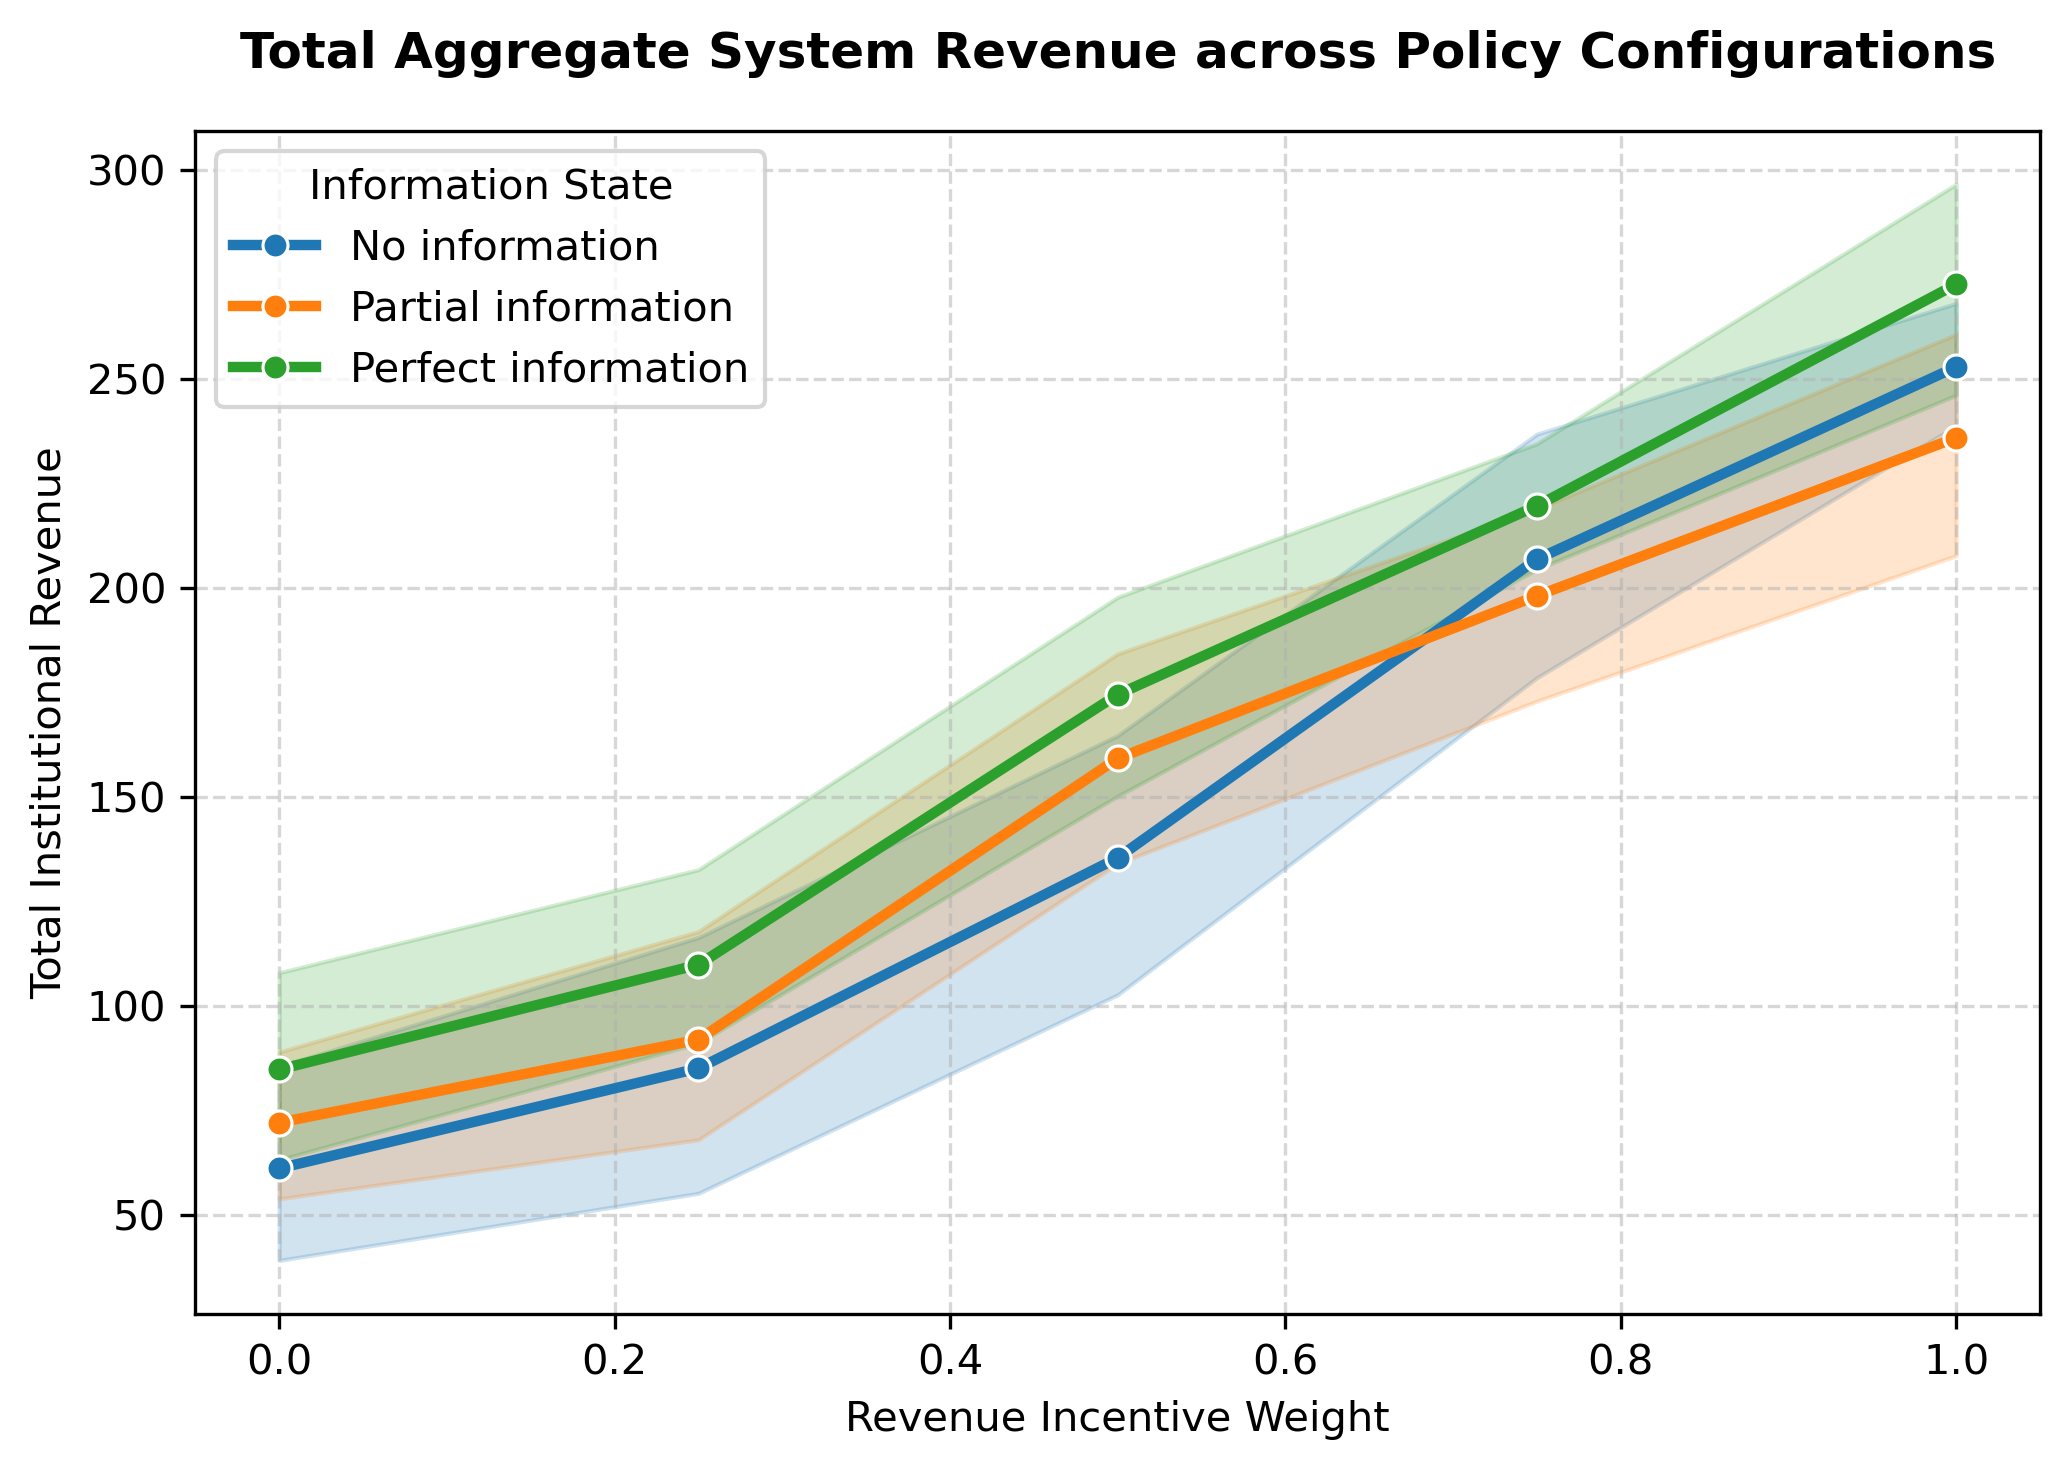

In [43]:
plt.figure(figsize=(7, 5), dpi=300)
sns.lineplot(
    data=df_clean,
    x="incentive",
    y="Total_Revenue",
    hue="information",
    marker="o",
    linewidth=2.5
)
plt.title("Total Aggregate System Revenue across Policy Configurations", fontsize=12, fontweight='bold', pad=15)
plt.ylabel("Total Institutional Revenue", fontsize=10)
plt.xlabel("Revenue Incentive Weight", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Information State", frameon=True)
plt.tight_layout()

plt.savefig("total_revenue_plot.png", bbox_inches="tight")
plt.show()